In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def transpune_matrice(A):
    randuri = len(A)
    coloane = len(A[0]) if randuri > 0 else 0
    return [[A[i][j] for i in range(randuri)] for j in range(coloane)]

def inmulteste_matrici(A, B):
    randuri_A = len(A)
    randuri_B = len(B)
    coloane_A = len(A[0]) if randuri_A > 0 else 0
    coloane_B = len(B[0]) if randuri_B > 0 else 0

    C = [[0.0 for _ in range(coloane_B)] for _ in range(randuri_A)]
    for i in range(randuri_A):
        for j in range(coloane_B):
            for k in range(coloane_A):
                C[i][j] += A[i][k] * B[k][j]
    return C

def inverseaza_matrice(A):
    n = len(A)
    aug = []
    for i in range(n):
        rand = list(A[i])
        identitate = [1.0 if j == i else 0.0 for j in range(n)]
        aug.append(rand + identitate)
    
    for i in range(n):
        pivot = aug[i][i]
        if pivot == 0:
            raise ValueError("Matrix is singular and cannot be inverted")
        for j in range(n * 2):
            aug[i][j] /= pivot
        for j in range(n):
            if j != i:
                factor = aug[j][i]
                for k in range(n * 2):
                    aug[j][k] -= factor * aug[i][k]
    return [row[n:] for row in aug]

def manual(X_sir, Y_sir):
    X = X_sir.tolist() if hasattr(X_sir, 'tolist') else X_sir
    Y = Y_sir.tolist() if hasattr(Y_sir, 'tolist') else Y_sir

    X_mat = []

    if isinstance (X[0], list):
        for rand in X:
            X_mat.append(rand + [1.0])
    else:
        for val in X:
            X_mat.append([val, 1.0])
    
    Y_mat = [[val] for val in Y]

    X_T = transpune_matrice(X_mat)
    X_T_X = inmulteste_matrici(X_T, X_mat)
    Inversa = inverseaza_matrice(X_T_X)
    X_T_Y = inmulteste_matrici(X_T, Y_mat)

    W_mat = inmulteste_matrici(Inversa, X_T_Y)

    return [w[0] for w in W_mat]

1. PIB: MSE = 0.43044589752514045, MAE = 0.5313759821925836


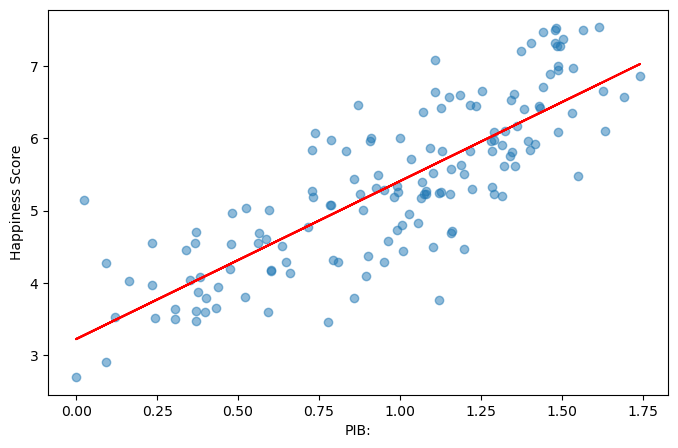

2. Familie: MSE = 0.544521409999717, MAE = 0.6176935026332236


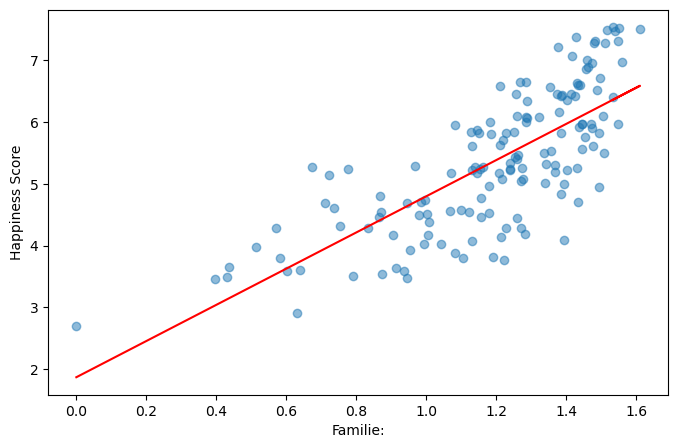

3. PIB + Liberatate: MSE = 0.3147618994738933, MAE = 0.4450301753348451


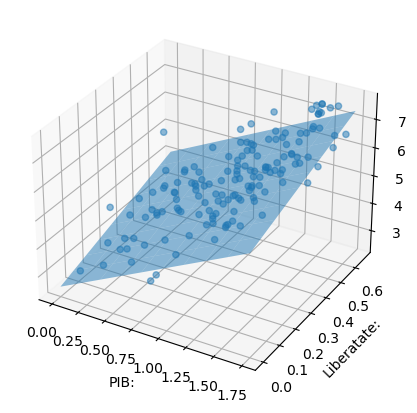

In [2]:
# file_name = "resources/v1_world-happiness-report-2017.csv"
# file_name = "resources/v2_world-happiness-report-2017.csv"
file_name = "resources/v3_world-happiness-report-2017.csv"
df = pd.read_csv(file_name)

col_gdp = "Economy..GDP.per.Capita."
col_family = "Family"
col_freedom = "Freedom"
col_happiness = "Happiness.Score"

df = df.dropna(subset=[col_gdp, col_family, col_freedom, col_happiness])

Y = df[col_happiness].values

#PIB
X_gdp = df[col_gdp].values
X_family = df[col_family].values
X_freedom = df[col_freedom].values

""" Version 1 """
# w1, b1 = np.polyfit(X_gdp, Y, 1)
# w2, b2 = np.polyfit(X_family, Y, 1)
# X_multi = np.column_stack((X_gdp, X_freedom, np.ones(len(X_gdp))))
# result = np.linalg.lstsq(X_multi, Y, rcond=None)[0]

""" Version 2 """
w1, b1 = manual(X_gdp, Y)
w2, b2 = manual(X_family, Y)
X_multi = np.column_stack((X_gdp, X_freedom))
result = manual(X_multi, Y)

#PIB

Y_est_gdp = w1 * X_gdp + b1
mse1 = np.mean((Y - Y_est_gdp) ** 2)
mae1 = np.mean(np.abs(Y - Y_est_gdp))

#Familie

Y_est_family = w2 * X_family + b2
mse2 = np.mean((Y - Y_est_family) ** 2)
mae2 = np.mean(np.abs(Y - Y_est_family))

#PIB + Liberatate

w3_gdp = result[0]
w3_freedom = result[1]
b3 = result[2]

Y_est_multi = w3_gdp * X_gdp + w3_freedom * X_freedom + b3

mse3 = np.mean((Y - Y_est_multi) ** 2)
mae3 = np.mean(np.abs(Y - Y_est_multi))

print(f"1. PIB: MSE = {mse1}, MAE = {mae1}")
plt.figure(figsize=(8, 5))
plt.scatter(X_gdp, Y, alpha=0.5)
plt.plot(X_gdp, Y_est_gdp, color='red')
plt.xlabel("PIB:")
plt.ylabel("Happiness Score")
plt.show()

print(f"2. Familie: MSE = {mse2}, MAE = {mae2}")
plt.figure(figsize=(8, 5))
plt.scatter(X_family, Y, alpha=0.5)

if X_family.min() == X_family.max():
    print("All countries have the same family value.")
    plt.axhline(y=Y_est_family[0], color='red', linestyle='--')
else:
    plt.plot(X_family, Y_est_family, color='red')
plt.xlabel("Familie:")
plt.ylabel("Happiness Score")
plt.show()

print(f"3. PIB + Liberatate: MSE = {mse3}, MAE = {mae3}")
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_gdp, X_freedom, Y, alpha=0.5)
x_surf, y_surf = np.meshgrid(
    np.linspace(X_gdp.min(), X_gdp.max(), 10),
    np.linspace(X_freedom.min(), X_freedom.max(), 10)
)
z_surf = w3_gdp * x_surf + w3_freedom * y_surf + b3

ax.plot_surface(x_surf, y_surf, z_surf, alpha=0.5)
ax.set_xlabel("PIB:")
ax.set_ylabel("Liberatate:")
ax.set_zlabel("Happiness Score")
plt.show()